In [ ]:
#objective
#the objective of this project is to analyze employee attrition data and identify key factors affecting employee turnover such as salary,department,experience,and job satisfaction


In [ ]:
#Tools and Technologies
.Excel (Data Cleaning)
. SQL Server (Data Analysis)
.Python (data Analysis & Visualization)
.Power BI (Dashboard)

In [15]:
#import required libraries
#data handling
import pandas as pd
import numpy as np
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
#Load Dataset
df = pd.read_excel("C:\\Users\\Manasa P\\Downloads\\archive\\HR_Employee attrition Analysis\\data\\2.HR_Attrition_Data_clean.xlsx", sheet_name="HR-Employee-Attrition")


In [17]:
df

,Age,Attrition,Department,Gender,Satisfaction,MaritalStatus,Salary,Experience,Attrition_Flag,Salary_Group,Experience_Group,Satisfaction_Group
0,41.0,Yes,Sales,Female,4.0,Single,5993.0,8.0,1.0,Medium,Medium,High
1,49.0,No,Research & Development,Male,2.0,Married,5130.0,10.0,0.0,Medium,experienced,Low
2,37.0,Yes,Research & Development,Male,3.0,Single,2090.0,7.0,1.0,Low,Medium,High
3,33.0,No,Research & Development,Female,3.0,Married,2909.0,8.0,0.0,Low,Medium,High
4,27.0,No,Research & Development,Male,2.0,Married,3468.0,6.0,0.0,Medium,Medium,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
1466,39.0,No,Research & Development,Male,1.0,Married,9991.0,9.0,0.0,High,Medium,Low
1467,27.0,No,Research & Development,Male,2.0,Married,6142.0,6.0,0.0,Medium,Medium,Low
1468,49.0,No,Sales,Male,2.0,Married,5390.0,17.0,0.0,Medium,experienced,Low
1469,34.0,No,Research & Development,Male,3.0,Married,4404.0,6.0,0.0,Medium,Medium,High


In [18]:
#Preview data
df.head()

,Age,Attrition,Department,Gender,Satisfaction,MaritalStatus,Salary,Experience,Attrition_Flag,Salary_Group,Experience_Group,Satisfaction_Group
0,41.0,Yes,Sales,Female,4.0,Single,5993.0,8.0,1.0,Medium,Medium,High
1,49.0,No,Research & Development,Male,2.0,Married,5130.0,10.0,0.0,Medium,experienced,Low
2,37.0,Yes,Research & Development,Male,3.0,Single,2090.0,7.0,1.0,Low,Medium,High
3,33.0,No,Research & Development,Female,3.0,Married,2909.0,8.0,0.0,Low,Medium,High
4,27.0,No,Research & Development,Male,2.0,Married,3468.0,6.0,0.0,Medium,Medium,Low


In [19]:
#Data understanding
#shape of data
df.shape

(1471, 12)

In [20]:
#Column names
df.columns

Index(['Age', 'Attrition', 'Department', 'Gender', 'Satisfaction',
       'MaritalStatus', 'Salary', 'Experience', 'Attrition_Flag',
       'Salary_Group', 'Experience_Group', 'Satisfaction_Group'],
      dtype='object')

In [21]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1470 non-null   float64
 1   Attrition           1470 non-null   object 
 2   Department          1470 non-null   object 
 3   Gender              1470 non-null   object 
 4   Satisfaction        1470 non-null   float64
 5   MaritalStatus       1470 non-null   object 
 6   Salary              1470 non-null   float64
 7   Experience          1470 non-null   float64
 8   Attrition_Flag      1470 non-null   float64
 9   Salary_Group        1470 non-null   object 
 10  Experience_Group    1471 non-null   object 
 11  Satisfaction_Group  1471 non-null   object 
dtypes: float64(5), object(7)
memory usage: 138.0+ KB


In [22]:
#ckeck missing values
df.isnull().sum()

Age                   1
Attrition             1
Department            1
Gender                1
Satisfaction          1
MaritalStatus         1
Salary                1
Experience            1
Attrition_Flag        1
Salary_Group          1
Experience_Group      0
Satisfaction_Group    0
dtype: int64

In [23]:
attrition_rate = df['Attrition_Flag'].mean()*100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


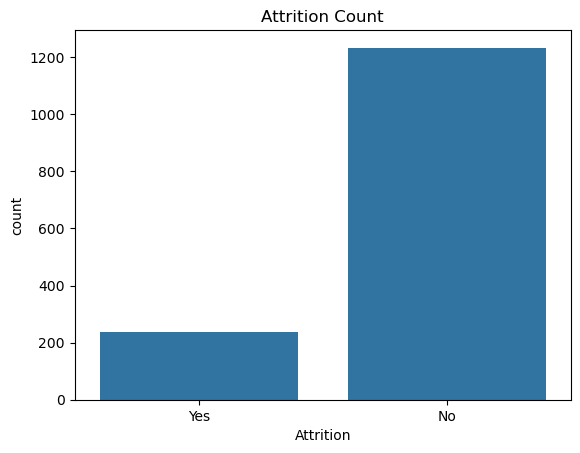

In [24]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Count")
plt.show()

In [25]:
# Department-Wise Attrition
dept_summary = df.groupby('Department').agg(
    Total_Employees=('Attrition_Flag', 'count'),
    Attrition_Rate=('Attrition_Flag', 'mean')
)

# Convert to percentage
dept_summary['Attrition_Rate'] = dept_summary['Attrition_Rate'] * 100

print(dept_summary)

                        Total_Employees  Attrition_Rate
Department                                             
Human Resources                      63       19.047619
Research & Development              961       13.839750
Sales                               446       20.627803


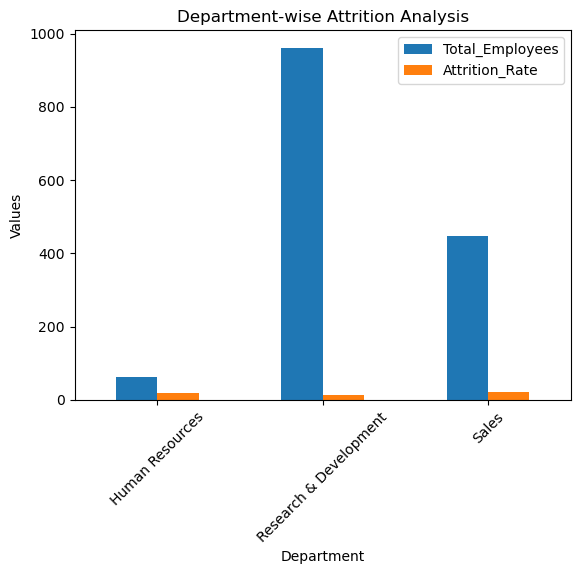

In [26]:
dept_summary.plot(kind='bar')
plt.title("Department-wise Attrition Analysis")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Salary vs Attrition
salary_attrition = df.groupby('Salary_Group')['Attrition_Flag'].mean() * 100
print(salary_attrition)

Salary_Group
High      10.804598
Low       28.607595
Medium    12.031250
Name: Attrition_Flag, dtype: float64


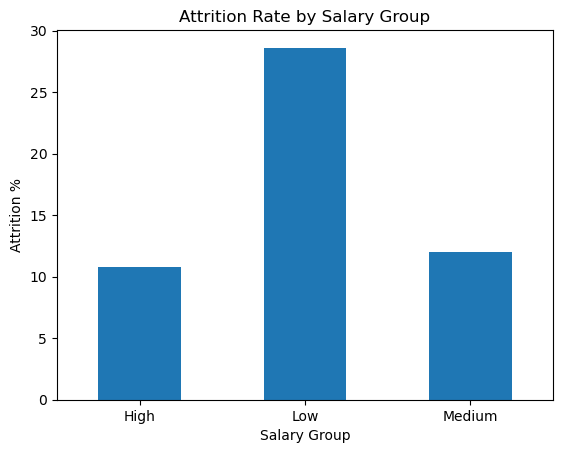

In [28]:
salary_attrition.plot(kind='bar')

plt.title("Attrition Rate by Salary Group")
plt.ylabel("Attrition %")
plt.xlabel("Salary Group")
plt.xticks(rotation=0)
plt.show()

C:\Users\Manasa P\AppData\Local\Temp\ipykernel_21312\1031458404.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('Age_Group')['Attrition_Flag'].mean() * 100


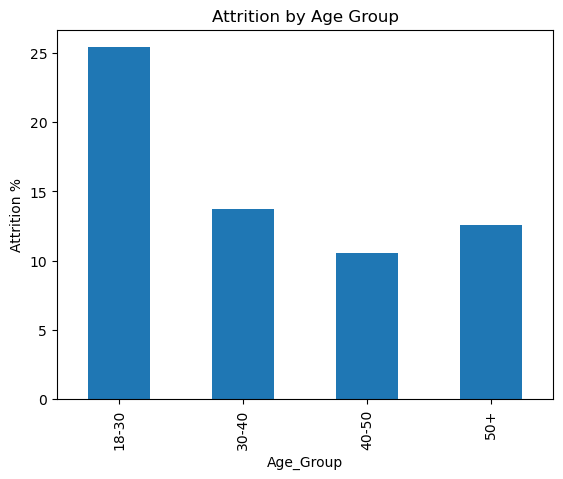

In [29]:
# Age-Wise Analysis
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18, 30, 40, 50, 60],
                        labels=['18-30', '30-40', '40-50', '50+'])

age_attrition = df.groupby('Age_Group')['Attrition_Flag'].mean() * 100

age_attrition.plot(kind='bar')
plt.title("Attrition by Age Group")
plt.ylabel("Attrition %")
plt.show()

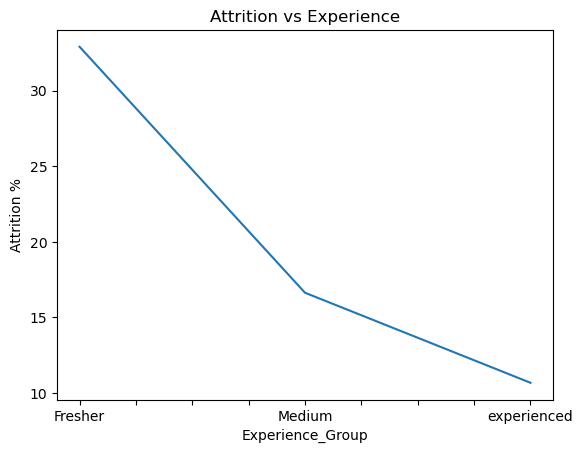

In [30]:
# Experience vs Attrition
exp_attrition = df.groupby('Experience_Group')['Attrition_Flag'].mean() * 100

exp_attrition.plot()
plt.title("Attrition vs Experience")
plt.ylabel("Attrition %")
plt.show()

In [31]:
# Satisfaction vs Attrition
satisfaction_attrition = df.groupby('Satisfaction_Group')['Attrition_Flag'].mean() * 100
print(satisfaction_attrition)

Satisfaction_Group
High    13.873474
Low     19.683656
Name: Attrition_Flag, dtype: float64


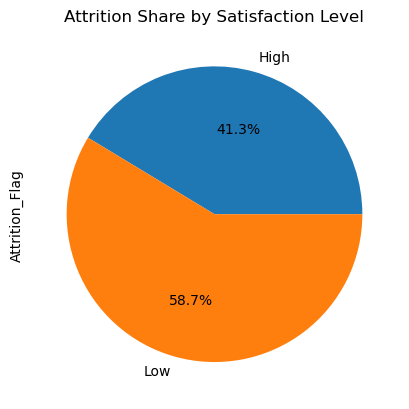

In [32]:
satisfaction_attrition.plot(kind='pie', autopct='%1.1f%%')
plt.title("Attrition Share by Satisfaction Level")
plt.show()

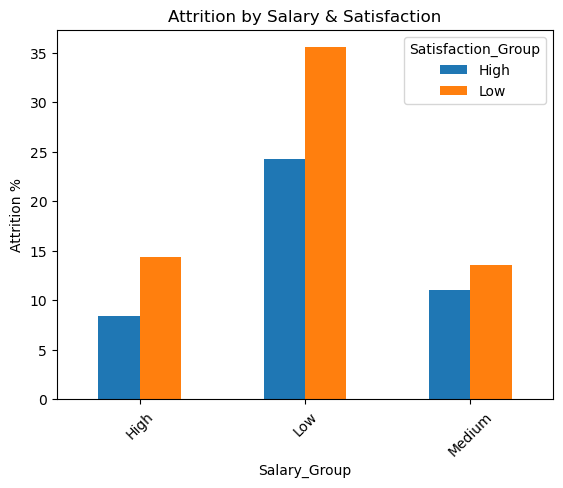

In [33]:
dept_sat = df.groupby(['Salary_Group', 'Satisfaction_Group'])['Attrition_Flag'].mean() * 100

dept_sat.unstack().plot(kind='bar')
plt.title("Attrition by Salary & Satisfaction")
plt.ylabel("Attrition %")
plt.xticks(rotation=45)
plt.show()

In [ ]:
## Final Insights:

###
1. The Sales department shows the highest attrition rate compared to other departments.

2. Employees in the low salary group are more likely to leave the company.

3. Younger employees (age group 18–30) have higher attrition rates.

4. Most employees leave within the first 0–2 years of joining.

5. Employees with low job satisfaction are more likely to leave.

6. Salary, satisfaction, and experience are the key factors influencing attrition.


In [ ]:
# Conclusion:
Attrition is mainly influenced by salary, department, age,experience and job Satisfaction. The company should focus on improving employee satisfaction, especially in high-risk groups, to reduce attrition.